In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
path = "../../data/raw/crops/soybean-production.csv"
soy= pd.read_csv(path)
soy.head() 

,Entity,Code,Year,Soybeans - Production (tonnes)
0,Afghanistan,AFG,2022,2906.0
1,Afghanistan,AFG,2023,6000.0
2,Afghanistan,AFG,2024,7304.9
3,Africa,OWID_AFR,1961,71813.0
4,Africa,OWID_AFR,1962,84594.0


In [5]:
soy_world = soy[soy["Entity"] == "World"].reset_index(drop=True)
soy_world.head()


,Entity,Code,Year,Soybeans - Production (tonnes)
0,World,OWID_WRL,1961,26883158.0
1,World,OWID_WRL,1962,27120148.0
2,World,OWID_WRL,1963,28207072.0
3,World,OWID_WRL,1964,29079548.0
4,World,OWID_WRL,1965,31704924.0


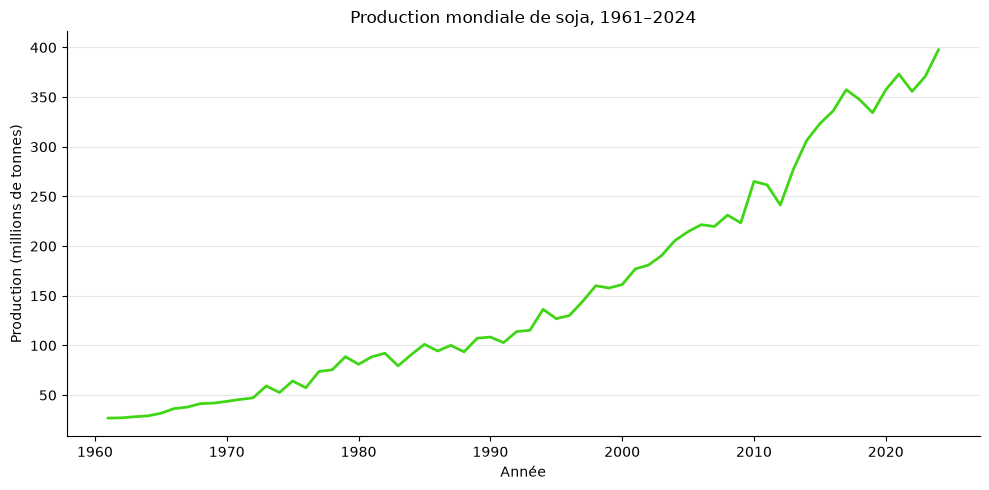

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(soy_world["Year"], soy_world["Soybeans - Production (tonnes)"] / 1e6, color="#40d616", linewidth=2)
ax.set_title("Production mondiale de soja, 1961–2024")
ax.set_xlabel("Année")
ax.set_ylabel("Production (millions de tonnes)")
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


In [7]:

soy_pays = soy[soy["Code"].notna() & ~soy["Code"].str.startswith("OWID_")]

prod_par_pays = (
    soy_pays.groupby("Entity")["Soybeans - Production (tonnes)"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"Entity": "pays", "Soybeans - Production (tonnes)": "production_totale_t"})
)
prod_par_pays.head(20)


,pays,production_totale_t
0,United States,4.163381e+09
1,Brazil,2.567028e+09
2,Argentina,1.270650e+09
3,China,7.698996e+08
4,India,3.248761e+08
5,Paraguay,2.102788e+08
6,Canada,1.579355e+08
7,Bolivia,6.629038e+07
8,Russia,6.397409e+07
9,Ukraine,5.963436e+07


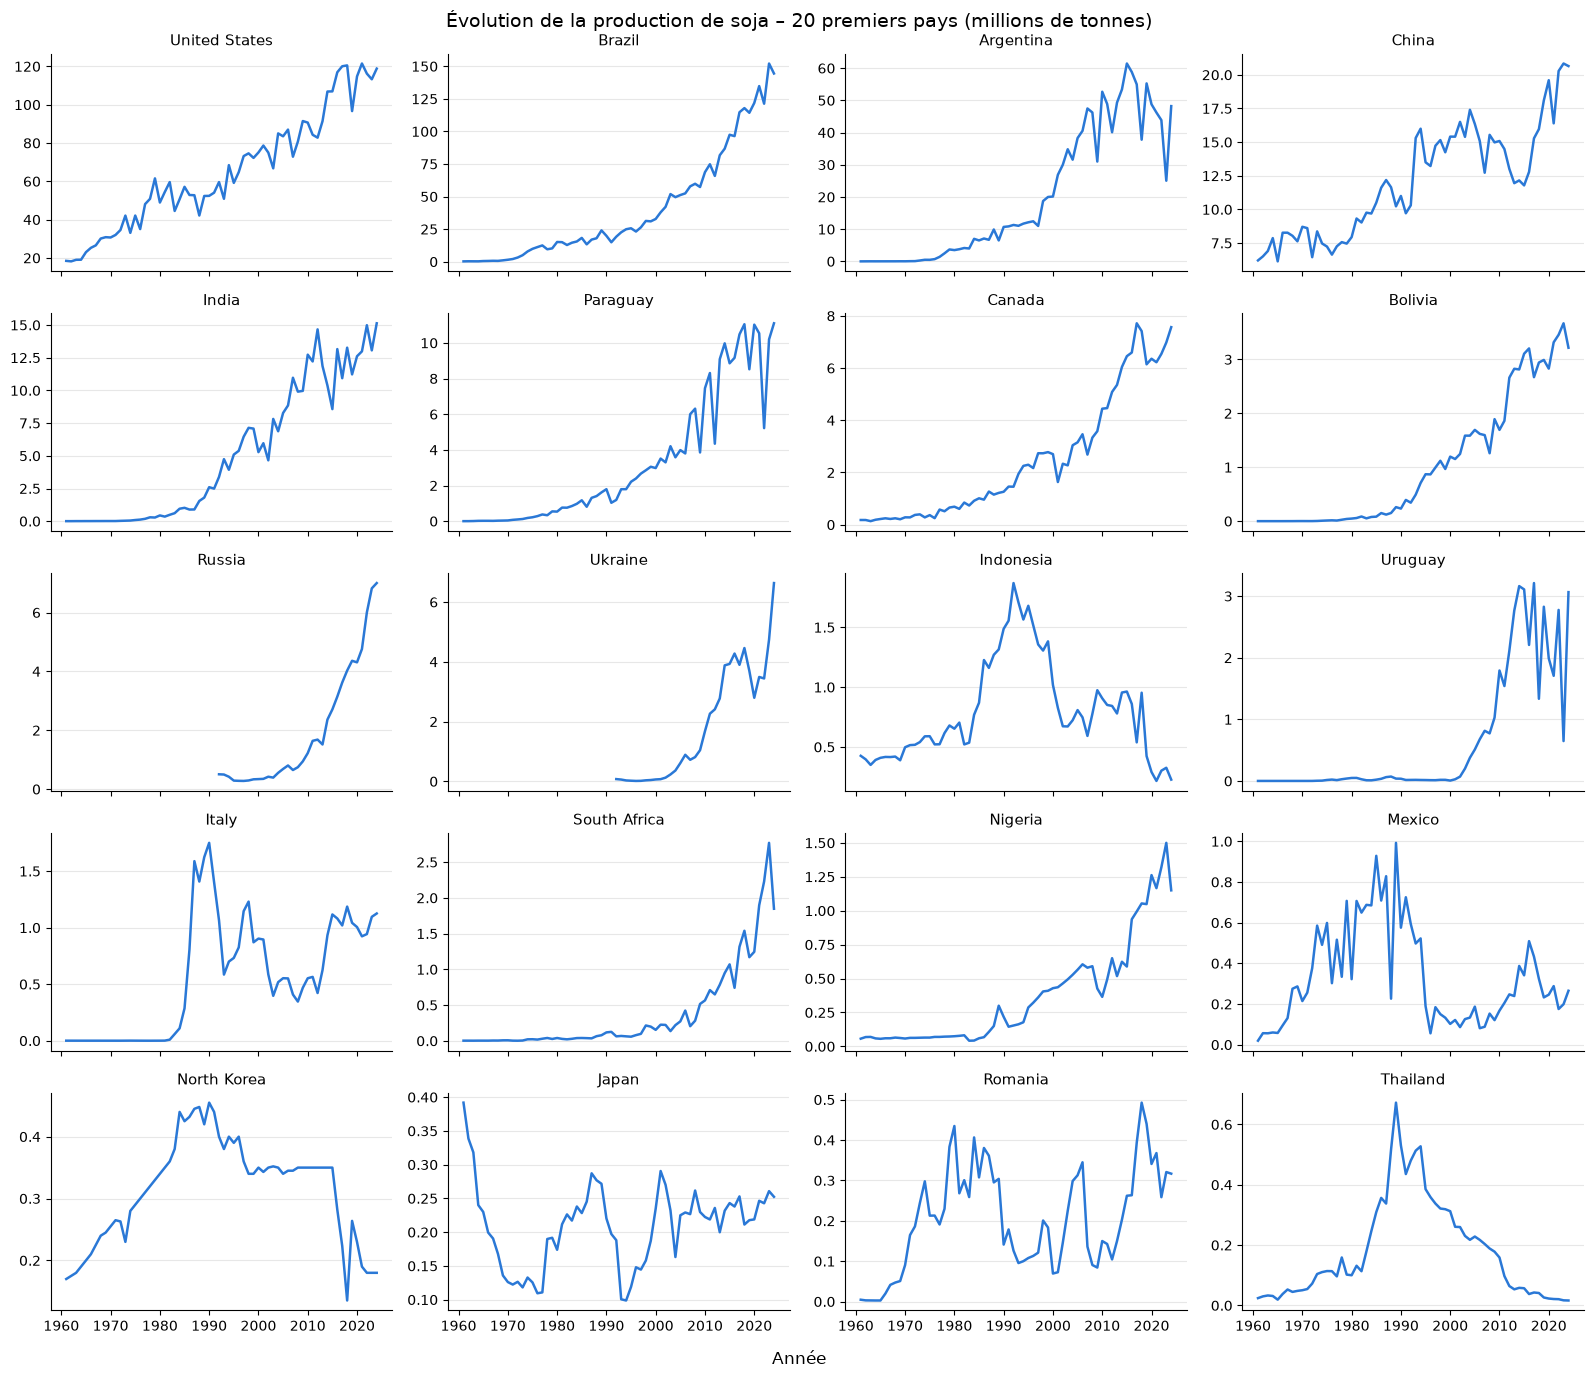

In [8]:
top20 = prod_par_pays.head(20)["pays"].tolist()
data = soy_pays[soy_pays["Entity"].isin(top20)]

fig, axes = plt.subplots(5, 4, figsize=(16, 14), sharex=True)
for ax, pays in zip(axes.flat, top20):
    d = data[data["Entity"] == pays]
    ax.plot(d["Year"], d["Soybeans - Production (tonnes)"] / 1e6, color="#2a78d6", linewidth=1.8)
    ax.set_title(pays, fontsize=11)
    ax.grid(axis="y", alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Évolution de la production de soja – 20 premiers pays (millions de tonnes)", fontsize=14)
fig.supxlabel("Année")
plt.tight_layout()
plt.show()


In [9]:
prod_par_pays["part_%"] = prod_par_pays["production_totale_t"] / prod_par_pays["production_totale_t"].sum() * 100
prod_par_pays.head

<bound method NDFrame.head of               pays  production_totale_t     part_%
0    United States         4.163381e+09  41.459014
1           Brazil         2.567028e+09  25.562504
2        Argentina         1.270650e+09  12.653155
3            China         7.698996e+08   7.666673
4            India         3.248761e+08   3.235121
..             ...                  ...        ...
113        Finland         0.000000e+00   0.000000
114          Malta         0.000000e+00   0.000000
115         Latvia         0.000000e+00   0.000000
116        Ireland         0.000000e+00   0.000000
117        Estonia         0.000000e+00   0.000000

[118 rows x 3 columns]>